<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 4.06e-04 | train loss 0.9415 acc 0.631 | val loss 0.7670 acc 0.657 *


[ResNet-50] Epoch   2/100 | LR: 4.06e-04 | train loss 0.6302 acc 0.756 | val loss 0.5584 acc 0.748 *


[ResNet-50] Epoch   3/100 | LR: 4.06e-04 | train loss 0.5906 acc 0.799 | val loss 0.5422 acc 0.777 *


[ResNet-50] Epoch   4/100 | LR: 4.06e-04 | train loss 0.3535 acc 0.864 | val loss 0.7509 acc 0.786


...

[ResNet-50] Epoch  12/100 | LR: 4.06e-04 | train loss 0.1105 acc 0.965 | val loss 0.7440 acc 0.824


[ResNet-50] Epoch  13/100 | LR: 4.06e-04 | train loss 0.0252 acc 0.995 | val loss 1.0390 acc 0.792


[ResNet-50] Epoch  14/100 | LR: 4.06e-04 | train loss 0.1168 acc 0.969 | val loss 0.8710 acc 0.786


[ResNet-50] Epoch  15/100 | LR: 4.06e-04 | train loss 0.0662 acc 0.979 | val loss 0.7658 acc 0.812


[ResNet-50] Epoch  16/100 | LR: 4.06e-04 | train loss 0.0156 acc 0.995 | val loss 0.8855 acc 0.809

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 16.

[ResNet-50] Restored best checkpoint (val loss = 0.5117)


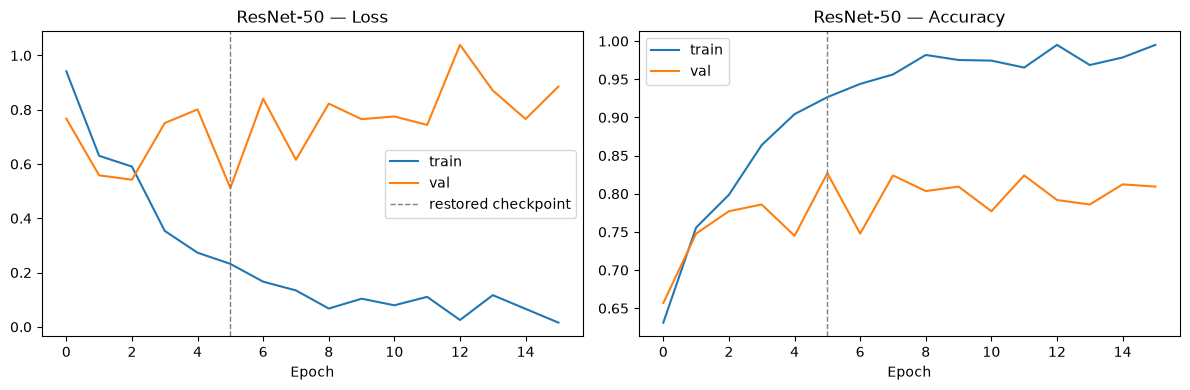

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.789


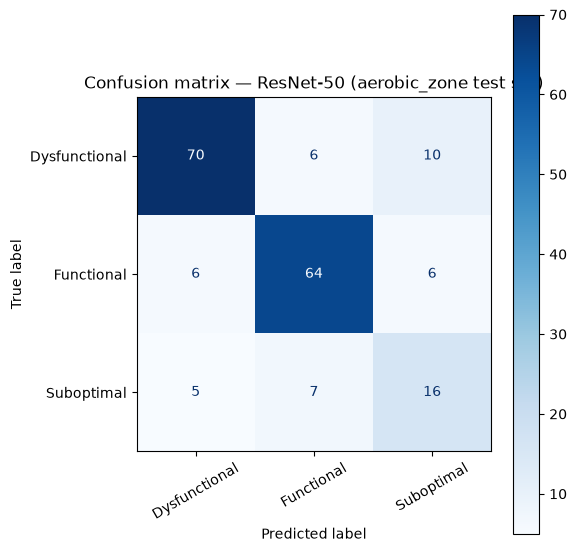

               precision    recall  f1-score   support

Dysfunctional      0.864     0.814     0.838        86
   Functional      0.831     0.842     0.837        76
   Suboptimal      0.500     0.571     0.533        28

     accuracy                          0.789       190
    macro avg      0.732     0.742     0.736       190
 weighted avg      0.797     0.789     0.793       190



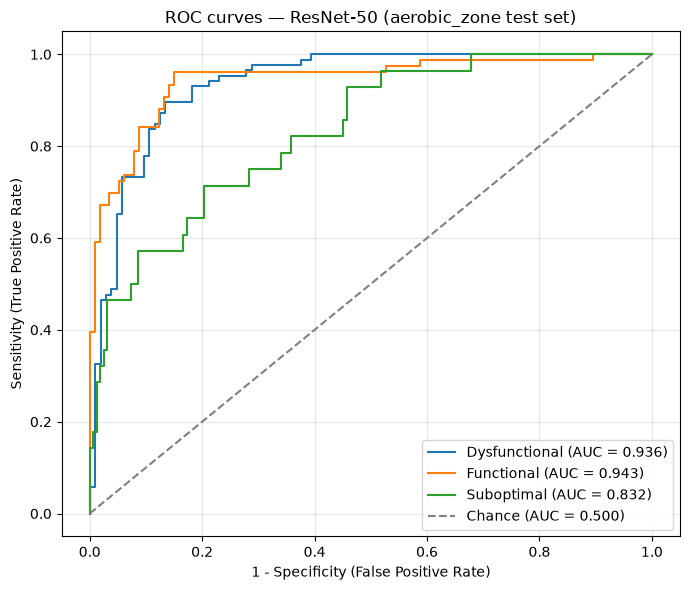

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.936
  Functional     : 0.943
  Suboptimal     : 0.832

Mean AUC (over 3/3 classes with test examples): 0.904


(np.float64(0.7894736842105263),
 {'Dysfunctional': 0.936381932021467,
  'Functional': 0.9426361957525392,
  'Suboptimal': 0.8315696649029983})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/aerobic_zone_noaug/results_aerobic_zone_resnet50_stratified.pkl
Saved model weights to ../models/aerobic_zone_resnet50_cnn.pt
